<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/Titanic_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())
display(df.head(10))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


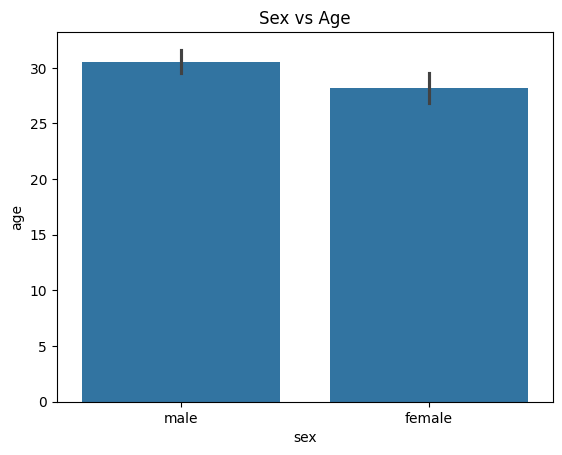

In [ ]:
sns.barplot(x='sex',y='age',data=df)
plt.title("Sex vs Age")
plt.show()

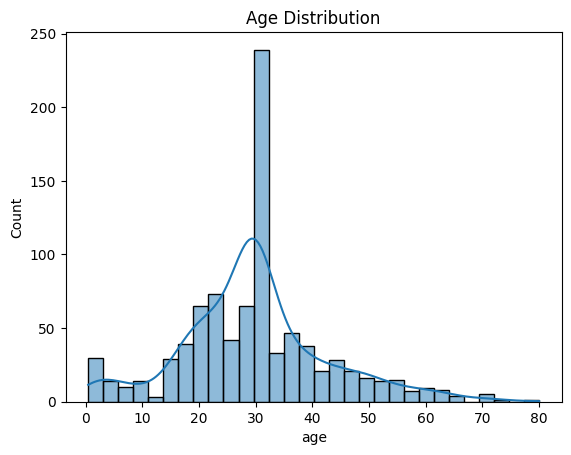

In [ ]:
sns.histplot(x='age',data=df,kde=True)
plt.title("Age Distribution")
plt.show()

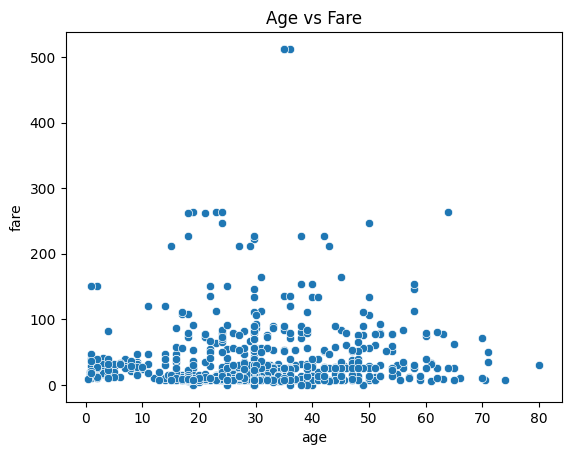

In [ ]:
sns.scatterplot(x='age',y='fare',data=df)
plt.title("Age vs Fare")
plt.show()

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Categorical: survived,sex,sibsp, embarked, who, adult_male, deck, embark_town, alive, alone

Ordinal: pclass (passenger class has an inherent order: 1st, 2nd, 3rd),class

Quantitative: age, fare

Temporal: While there isn't an explicit temporal column in this dataset, you could potentially derive temporal features if you had information about the date of the voyage

In [ ]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [ ]:
from pandas.api.types import CategoricalDtype

# Define the desired order of the categories
class_order = ['Third', 'Second', 'First']

# Create an ordered CategoricalDtype
ordered_class_dtype = CategoricalDtype(categories=class_order, ordered=True)

# Convert the 'class' column to the ordered categorical type
df['class'] = df['class'].astype(ordered_class_dtype)

# Verify the data type and the order
print(df['class'].dtype)
print(df['class'].head())

category
0    Third
1    First
2    Third
3    First
4    Third
Name: class, dtype: category
Categories (3, object): ['Third' < 'Second' < 'First']


In [ ]:
%pip install treelib

In [ ]:
from treelib import Node, Tree

# Create a tree
tree = Tree()

# Add the root node
tree.create_node("Passenger Class", "root")

# Add class nodes as children of the root
tree.create_node("First", "first", parent="root")
tree.create_node("Second", "second", parent="root")
tree.create_node("Third", "third", parent="root")

# Display the tree
tree.show()

Passenger Class
├── First
├── Second
└── Third



In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.datasets import load_iris

# 1. Load the Iris dataset from sklearn
iris_data = load_iris()
iris = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris['species'] = iris_data.target_names[iris_data.target]

# 2. Create Categorical Bins for Petal Length and Sepal Length
# This step creates the required hierarchy: Species -> Petal_Size -> Sepal_Size

# Define Petal Length Bins
bins_petal = [0, 1.5, 4.8, iris['petal length (cm)'].max() + 0.1]
labels_petal = ['Small_Petal', 'Medium_Petal', 'Large_Petal']
iris['Petal_Size'] = pd.cut(
    iris['petal length (cm)'],
    bins=bins_petal,
    labels=labels_petal,
    right=False
)

# Define Sepal Length Bins
bins_sepal = [4.0, 5.5, 6.5, iris['sepal length (cm)'].max() + 0.1]
labels_sepal = ['Short_Sepal', 'Avg_Sepal', 'Long_Sepal']
iris['Sepal_Size'] = pd.cut(
    iris['sepal length (cm)'],
    bins=bins_sepal,
    labels=labels_sepal,
    right=False
)

# 3. Add a 'Count' column for the sunburst size
iris['Count'] = 1

# 4. Create the Sunburst Chart
# The 'path' parameter defines the hierarchy from the center outward.
fig_sunburst = px.sunburst(
    iris,
    path=['species', 'Petal_Size', 'Sepal_Size'], # Hierarchy defined here
    values='Count',
    color='species',  # Color the segments based on the outermost ring
    title='Hierarchical Distribution of Iris Species by Flower Size'
)

# Display the interactive figure
fig_sunburst.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)


In [ ]:
import pandas as pd
import plotly.express as px
# --- SIMULATED INDIAN TEMPERATURE DATA (Used to create the scalar map) ---
# Approximate centroids (latitude/longitude) and simulated temperatures for major states/regions
lat_lon_data = {
    'State': ['Maharashtra', 'Delhi', 'Tamil Nadu', 'West Bengal', 'Rajasthan', 'Karnataka', 'Gujarat', 'Uttar Pradesh'],
    'Latitude': [19.0, 28.6, 13.0, 22.5, 26.9, 12.9, 23.0, 26.8],
    'Longitude': [72.8, 77.2, 80.2, 88.3, 75.7, 77.5, 72.5, 80.9],
    'Temperature_C': [32, 28, 35, 30, 38, 26, 36, 34],
}
df_map = pd.DataFrame(lat_lon_data)


# Create the scatter map (Color-Coded Scalar Map)
fig = px.scatter_geo(
    df_map,
    lat='Latitude',
    lon='Longitude',
    color='Temperature_C',      # The scalar value (temperature) is mapped to color
    size='Temperature_C',       # Size markers by temperature for emphasis
    hover_name='State',         # Show state name on hover
    scope='asia',               # Start with the Asia scope
    title='Temperature Variation Across India (Simulated Data)',
    color_continuous_scale="Reds" # Use a red scale where darker/larger = hotter
)

# Set the map to focus specifically on the geographic bounds of India
fig.update_geos(
    lataxis_range=[5, 35],      # Focus on Southern to Northern India
    lonaxis_range=[65, 95],     # Focus on Western to Eastern India
    showcountries=True,
    countrycolor="Gray",
    subunitcolor="Black"
)

fig.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

df = pd.read_csv('GlobalLandTemperaturesByCity.csv')
df.head()


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [ ]:
df = df[(df['Country']=='India') & (df['dt']>='2000-01-01')]
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
52086,2000-01-01,13.192,0.744,Abohar,India,29.74N,73.85E
52087,2000-02-01,14.853,0.269,Abohar,India,29.74N,73.85E
52088,2000-03-01,21.473,0.415,Abohar,India,29.74N,73.85E
52089,2000-04-01,30.352,0.388,Abohar,India,29.74N,73.85E
52090,2000-05-01,35.242,0.529,Abohar,India,29.74N,73.85E


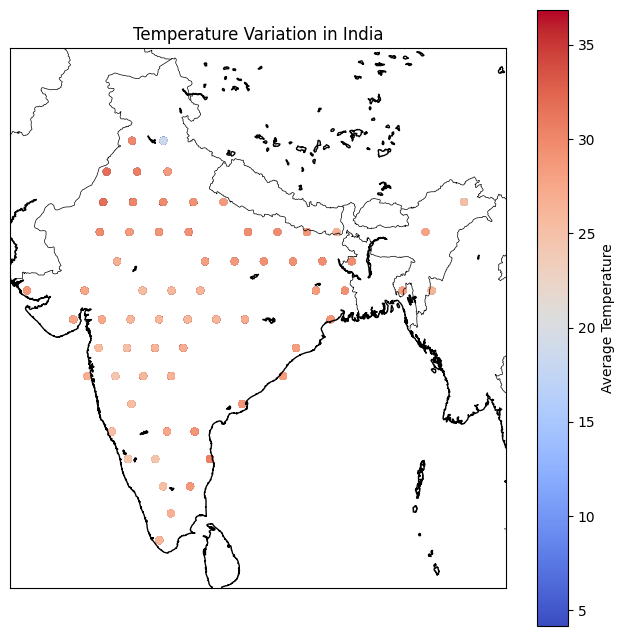

In [ ]:
df['Latitude'] = df['Latitude'].apply(lambda x: float(x[:-1]) * (-1 if x[-1] == 'S' else 1))
df['Longitude'] = df['Longitude'].apply(lambda x: float(x[:-1]) * (-1 if x[-1] == 'W' else 1))

plt.figure(figsize=(8, 8))
m = Basemap(projection='merc', llcrnrlat=6, urcrnrlat=36, llcrnrlon=68, urcrnrlon=98, resolution='i')
m.drawcountries()
m.drawcoastlines()

x,y=m(df['Longitude'].values,df['Latitude'].values)
sc=m.scatter(x,y,c=df['AverageTemperature'],cmap='coolwarm',s=20)
plt.colorbar(sc,label='Average Temperature')
plt.title('Temperature Variation in India')
plt.show()